In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from torchvision.datasets import ImageFolder

dataset_path = "/content/drive/MyDrive/PCB_PROJECT/PCB_DATASET/images"

train_dataset = ImageFolder(dataset_path)

print(train_dataset.classes)

['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


**SPLIT DATASET**

In [ ]:
import os
import shutil
import random

roi_path = "/content/drive/MyDrive/PCB_PROJECT/outputs/roi_images"

dataset_path = "/content/drive/MyDrive/PCB_PROJECT/dataset"

train_path = os.path.join(dataset_path,"train")
val_path = os.path.join(dataset_path,"val")
test_path = os.path.join(dataset_path,"test")

for path in [train_path,val_path,test_path]:
    os.makedirs(path,exist_ok=True)

for defect_class in os.listdir(roi_path):

    class_path = os.path.join(roi_path,defect_class)

    images = os.listdir(class_path)

    random.shuffle(images)

    train_split = int(0.7 * len(images))
    val_split = int(0.85 * len(images))

    train_imgs = images[:train_split]
    val_imgs = images[train_split:val_split]
    test_imgs = images[val_split:]

    for folder in [train_path,val_path,test_path]:
        os.makedirs(os.path.join(folder,defect_class),exist_ok=True)

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(train_path,defect_class,img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(val_path,defect_class,img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(test_path,defect_class,img)
        )

print("Dataset split completed")

KeyboardInterrupt: 

CHECK IMAGES IN EACH SPLIT

In [ ]:
for split in ["train","val","test"]:
    print(split)
    path = f"/content/drive/MyDrive/PCB_PROJECT/dataset/{split}"

    for c in os.listdir(path):
        print(c,len(os.listdir(os.path.join(path,c))))

    print()

train
Spurious_copper 353
Spur 341
Short 343
Open_circuit 337
Missing_hole 347
Mouse_bite 344

val
Spurious_copper 75
Spur 73
Short 74
Open_circuit 72
Missing_hole 75
Mouse_bite 74

test
Spurious_copper 76
Spur 74
Short 74
Open_circuit 73
Missing_hole 75
Mouse_bite 74



**MODEL TRAINING**

In [ ]:
!pip install timm

In [ ]:
import torch
import timm
import numpy as np
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
dataset_path = "/content/drive/MyDrive/PCB_PROJECT/dataset"

In [ ]:
import torch
print(torch.cuda.is_available())

False


DATA PREPROCESS AND AUGUMENTATION

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [ ]:
print(train_transforms)

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
)


**LOAD DATASET**

In [ ]:
train_dataset = datasets.ImageFolder(
    dataset_path + "/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    dataset_path + "/val",
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    dataset_path + "/test",
    transform=val_transforms
)

print("Classes:", train_dataset.classes)

Classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


In [ ]:
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 2064
Val size: 443
Test size: 446


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

**LOAD EFFICIENTNET MODEL**

In [ ]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=6
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(device)

cpu


LOSS AND OPTIMIZER

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003
)

**TRAINING LOOP**

In [ ]:
for epoch in range(10):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total

    print("Epoch:",epoch+1,
          "Loss:",running_loss,
          "Train Accuracy:",train_acc)

Epoch: 1 Loss: 180.55274848267436 Train Accuracy: 67.63565891472868
Epoch: 2 Loss: 35.433010443812236 Train Accuracy: 91.95736434108527
Epoch: 3 Loss: 25.738481766311452 Train Accuracy: 94.5251937984496
Epoch: 4 Loss: 9.714758969668765 Train Accuracy: 97.57751937984496
Epoch: 5 Loss: 10.407187567645451 Train Accuracy: 97.48062015503876
Epoch: 6 Loss: 5.298360724953767 Train Accuracy: 98.54651162790698
Epoch: 7 Loss: 5.485827487598044 Train Accuracy: 98.40116279069767
Epoch: 8 Loss: 8.671218252969993 Train Accuracy: 98.25581395348837
Epoch: 9 Loss: 4.094271330096035 Train Accuracy: 99.17635658914729
Epoch: 10 Loss: 6.568899931611668 Train Accuracy: 98.69186046511628


VALIDATION ACCURACY

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_acc = 100 * correct / total

print("Validation Accuracy:", val_acc)

Validation Accuracy: 98.64559819413093


TEST ACCURACY

In [ ]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total

print("Test Accuracy:", test_acc)

Test Accuracy: 98.87892376681614


CONFUSION MATRIX

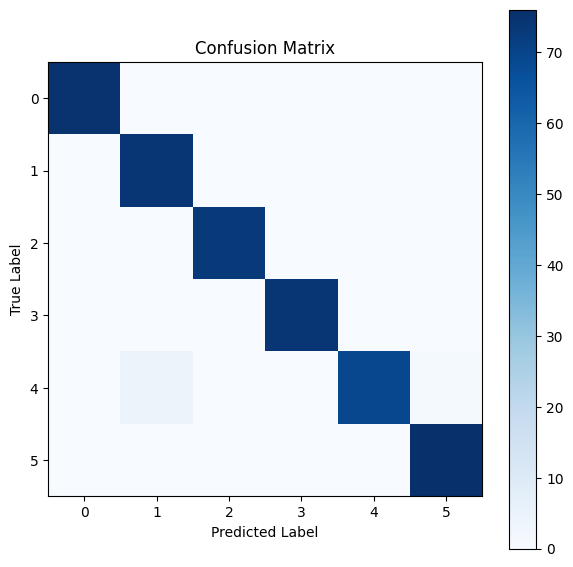

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,7))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.show()

SAVE THE MODEL

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/PCB_PROJECT/pcb_defect_model.pth"
)